# Predicting 30-Day Hospital Readmission for Diabetic Patients
## Phase 1: Exploratory Data Analysis, Preprocessing & Feature Engineering

---

### Executive Summary

- **Problem:** Hospital readmissions within 30 days cost the US healthcare system an estimated \$26 billion annually. We build a binary classifier to identify high-risk diabetic patients at discharge.
- **Data:** 101,766 clinical encounters across 130 US hospitals (1999--2008), reduced to ~70,000 unique patients after deduplication.
- **Class imbalance:** Only ~9% of patients are readmitted within 30 days, making accuracy a misleading metric. Precision, recall, and F1 are essential.
- **Key predictors:** Prior hospitalization history (`number_inpatient`, `number_emergency`) and discharge disposition show the strongest associations with readmission.
- **Final dataset:** 98 engineered features, split 80/20 with stratification, ready for modeling in Phase 2.

---

## 1. Problem Definition

**Goal:** Predict whether a diabetic patient will be readmitted to the hospital within 30 days of discharge.

Unplanned hospital readmissions represent a significant burden on healthcare systems worldwide. In the United States alone, the Centers for Medicare & Medicaid Services estimates that avoidable readmissions cost over **\$26 billion per year**. For patients with diabetes mellitus -- a complex chronic condition requiring careful management of blood glucose, medications, and comorbidities -- readmission rates are particularly elevated.

Early identification of patients at high risk of 30-day readmission enables targeted interventions: follow-up calls, medication reconciliation, care coordination, and transitional care programs. Machine learning offers a systematic, data-driven approach to this prediction task.

**Dataset:** Diabetes 130-US Hospitals for Years 1999--2008  
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/296)  
**Reference:** Strack, B., DeShazo, J.P., et al. *"Impact of HbA1c Measurement on Hospital Readmission Rates."* BioMed Research International, 2014.  
**Dimensions:** 101,766 encounters x 50 features  

**Target formulation:**  
The original `readmitted` column has three values: `<30` (within 30 days), `>30` (after 30 days), and `NO`. We binarize this into **1** (readmitted within 30 days) vs. **0** (all other outcomes), framing the task as a clinically actionable binary classification problem.

#### Feature Taxonomy

| Group | Features | Measurement Scale |
|-------|----------|------------------|
| **Demographics** | race, gender, age | Nominal, Nominal, Ordinal |
| **Admission context** | admission_type_id, discharge_disposition_id, admission_source_id | Nominal (integer-coded) |
| **Encounter metrics** | time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_diagnoses | Ratio |
| **Prior utilization** | number_outpatient, number_emergency, number_inpatient | Ratio |
| **Diagnoses** | diag_1, diag_2, diag_3 | Nominal (ICD-9 codes, high cardinality) |
| **Laboratory results** | max_glu_serum, A1Cresult | Ordinal |
| **Medications** | 23 drug columns (metformin, insulin, etc.) | Ordinal (No / Steady / Up / Down) |
| **Clinical flags** | change, diabetesMed | Binary |

---

## 2. Data Loading & Initial Inspection

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_data, load_ids_mapping
from src.eda import (
    missing_summary, plot_missing_bar, plot_target_distribution,
    plot_numeric_histograms, compute_skewness, plot_categorical_bars,
    medication_variance_analysis, plot_bivariate_boxplots,
    plot_stacked_proportions, plot_scatter, detect_outliers_iqr,
    plot_outlier_boxplots, plot_correlation_heatmap,
    correlation_with_target, find_multicollinear
)
from src.preprocessing import (
    drop_ids, drop_high_missing, drop_nzv_medications,
    remove_deceased, remove_invalid_gender, impute_missing,
    encode_age, encode_medications, encode_lab_results,
    encode_binaries, group_diagnoses, one_hot_encode_categoricals,
    cap_outliers, scale_features
)
from src.feature_engineering import (
    create_visit_features, create_med_change_feature,
    create_test_flags, create_service_utilization,
    bin_time_in_hospital, log_transform_skewed, remove_low_variance
)
from src.utils import MEDICATION_COLS, print_step

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Environment ready.')

Environment ready.


In [2]:
df = load_data('../data/raw/diabetic_data.csv')
ids_mapping = load_ids_mapping('../data/raw/IDs_mapping.csv')
print(f'Loaded: {df.shape[0]:,} encounters x {df.shape[1]} features')

Loaded: 101,766 encounters x 50 features


In [3]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [4]:
df.describe(include='object')

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,99493,101766,101766,3197,61510,51817,101745,101408,100343,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,5,3,10,9,17,72,716,748,789,4,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),[75-100),MC,InternalMedicine,428,276,250,None,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,1336,32439,14635,6862,6752,11555,96420,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


> **Key Takeaway:** The dataset contains a rich mixture of continuous encounter metrics, ordinal laboratory results, high-cardinality diagnosis codes, and binary flags. The wide range of numeric scales (e.g., `num_lab_procedures` up to 132 vs. `number_emergency` near 0 for most patients) confirms that standardization will be necessary for distance-based algorithms.

---

## 3. Missing Values Analysis

**Goal:** Identify the extent, pattern, and mechanism of missing data to determine appropriate treatment.

Following Rubin's (1976) taxonomy, missing data falls into three categories:
- **MCAR** (Missing Completely At Random): Missingness is independent of both observed and unobserved data.
- **MAR** (Missing At Random): Missingness depends on observed data but not on the missing values themselves.
- **MNAR** (Missing Not At Random): Missingness depends on the unobserved values -- the most problematic case.

In [5]:
miss = missing_summary(df)
print(miss.to_string())

                   missing_count  missing_pct
weight                     98569    96.858479
medical_specialty          49949    49.082208
payer_code                 40256    39.557416
race                        2273     2.233555
diag_3                      1423     1.398306
diag_2                       358     0.351787
diag_1                        21     0.020636


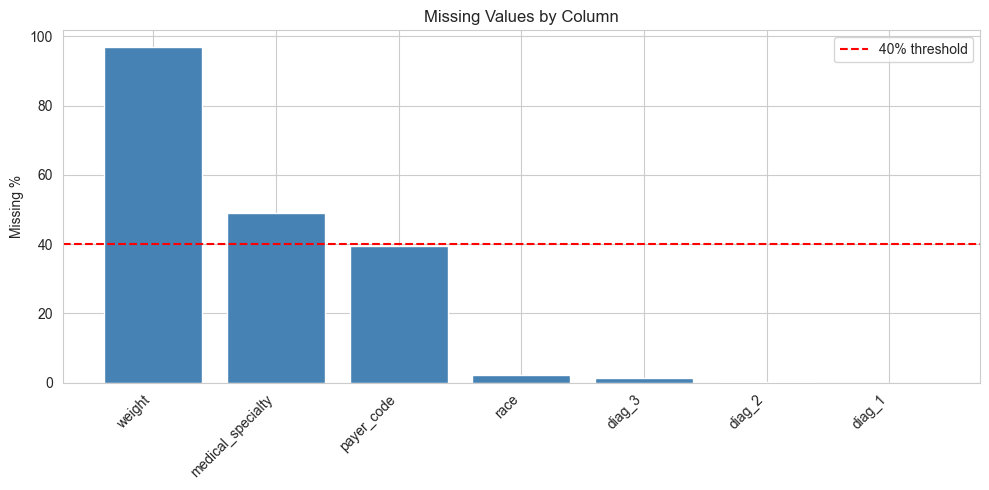

In [6]:
plot_missing_bar(miss, threshold=40)

#### Missing Data Classification & Decisions

A widely adopted heuristic in applied ML is to discard features with more than 40% missingness, as imputation at that scale introduces more noise than signal (Schafer & Graham, 2002).

| Column | Missing % | Mechanism | Rationale | Action |
|--------|-----------|-----------|-----------|--------|
| `weight` | ~97% | **MNAR** | Weight recording depends on clinical workflow and, plausibly, on the weight itself | **Drop** |
| `medical_specialty` | ~49% | **MAR** | Missingness correlates with admission pathway (emergency vs. elective) | **Drop** |
| `payer_code` | ~40% | **MAR** | Administrative variable; limited clinical relevance to readmission | **Drop** |
| `race` | ~2% | **MCAR** | Small, likely random omissions | **Impute (mode)** |
| `diag_1/2/3` | <2% | **MAR** | Secondary diagnoses absent for simpler cases | **Impute ('Missing' category)** |

> **Key Takeaway:** Three columns exceed the 40% threshold and are dropped. The remaining missingness is minimal and safely imputable.

---

## 4. Patient Deduplication & Data Leakage Prevention

**Goal:** Ensure statistical independence between observations to prevent information leakage.

In [7]:
print(f'Total encounters:  {len(df):,}')
print(f'Unique patients:   {df["patient_nbr"].nunique():,}')
print(f'Avg encounters/pt: {len(df) / df["patient_nbr"].nunique():.2f}')

Total encounters:  101,766
Unique patients:   71,518
Avg encounters/pt: 1.42


In [8]:
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f'After deduplication: {df.shape[0]:,} unique patients')

After deduplication: 71,518 unique patients


If the same patient appears in both training and test sets, the model can memorize patient-specific patterns rather than learn generalizable readmission risk factors. By retaining only the first encounter per patient, we enforce independence -- a prerequisite for valid out-of-sample evaluation.

> **Key Takeaway:** Deduplication reduces the dataset by ~30% but is essential for honest evaluation. This is the first of three data leakage safeguards (the others: fit scaler on train only, stratified splitting).

---

## 5. Target Variable & Class Imbalance

**Goal:** Define the prediction target and characterize the class distribution.

In [9]:
print('Original 3-class distribution:')
print(df['readmitted'].value_counts())
print()

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df = df.drop(columns=['readmitted'])

positive_rate = df['readmitted_binary'].mean()
print(f'Binary target: {positive_rate:.1%} positive (readmitted <30 days)')
print(f'Imbalance ratio: 1:{(1-positive_rate)/positive_rate:.0f}')

Original 3-class distribution:
readmitted
NO     42985
>30    22240
<30     6293
Name: count, dtype: int64

Binary target: 8.8% positive (readmitted <30 days)
Imbalance ratio: 1:10


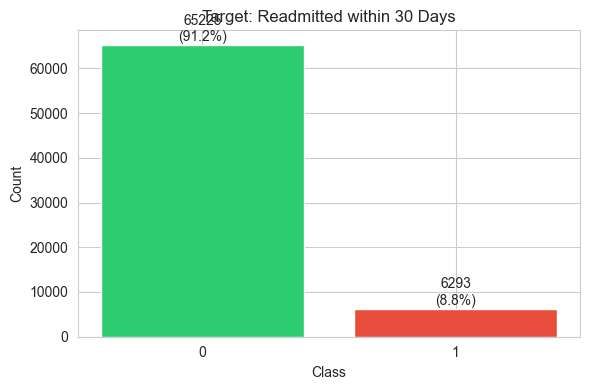

In [10]:
plot_target_distribution(df['readmitted_binary'], 'Target: Readmitted within 30 Days')

#### The Accuracy Paradox

With ~91% negative cases, a trivial classifier that always predicts *"not readmitted"* achieves 91% accuracy while identifying **zero** at-risk patients. This is the *accuracy paradox* (Valverde-Albacete & Pelaez-Moreno, 2014): in imbalanced settings, accuracy is misleading.

**Implications for Phase 2:**
- We will evaluate models using **precision** (of flagged patients, how many are truly readmitted?), **recall** (of truly readmitted patients, how many did we catch?), and **F1-score** (their harmonic mean).
- Stratified train-test splitting will preserve the class ratio in both partitions.
- Techniques like class weighting or oversampling may be explored.

> **Key Takeaway:** The ~1:10 class imbalance mandates that we evaluate with precision/recall/F1, not accuracy.

---

## 6. Univariate Analysis

**Goal:** Understand the marginal distribution of each feature to identify skewness, modality, and low-variance attributes.

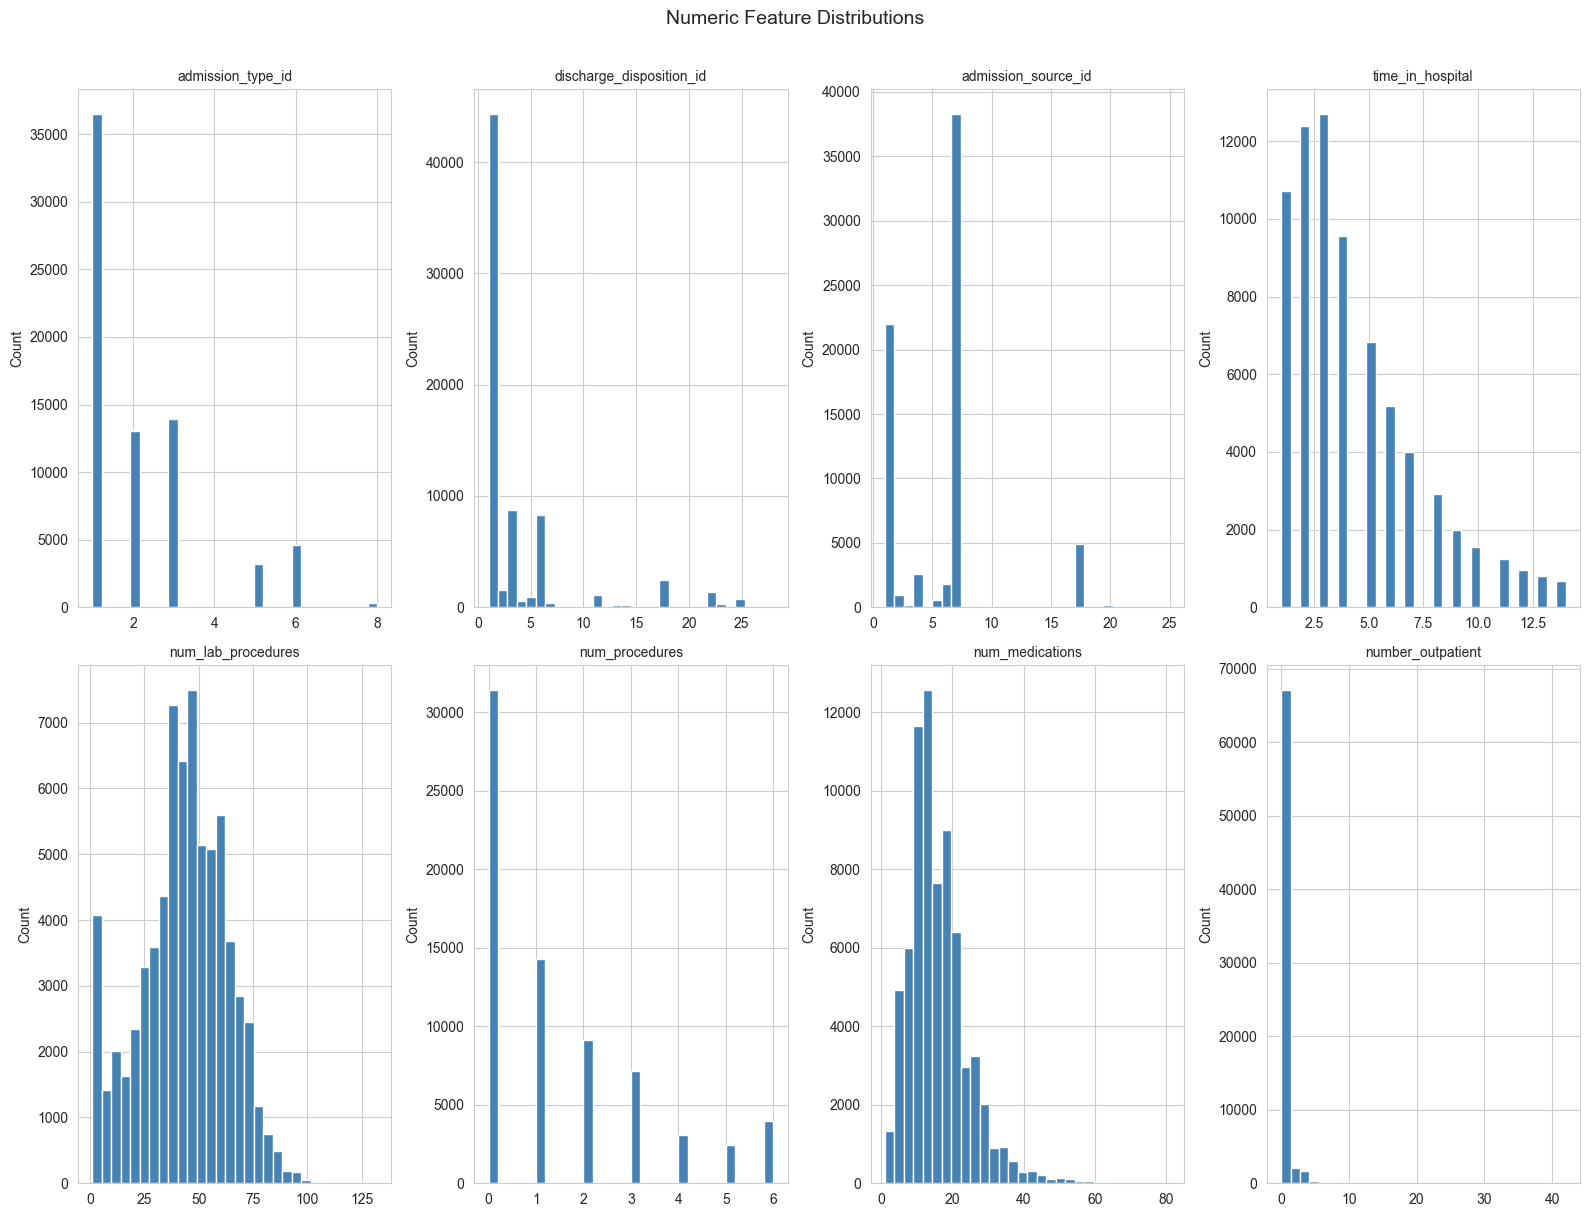

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
hist_cols = [c for c in numeric_cols if c not in ['encounter_id', 'patient_nbr', 'readmitted_binary']]
plot_numeric_histograms(df, hist_cols[:8])

**Distribution insights:**
- **`time_in_hospital`**: Right-skewed with mode at 2--3 days. Most admissions are short, with a tail extending to 14 days for complex cases.
- **`num_lab_procedures`**: Approximately Gaussian, centered around 40--50, reflecting standard diabetic monitoring protocols.
- **`number_outpatient / emergency / inpatient`**: Extreme zero-inflation with long right tails. The majority of patients have no prior visits; rare high values represent "frequent utilizers" -- a clinically important subgroup.

In [12]:
skew_df = compute_skewness(df, hist_cols)
print('Features with |skewness| > 1 (candidates for log transform):\n')
print(skew_df[skew_df['high_skew']].to_string())

Features with |skewness| > 1 (candidates for log transform):

                           skewness  abs_skewness  high_skew
number_emergency          21.149176     21.149176       True
number_outpatient          9.679206      9.679206       True
number_inpatient           5.545911      5.545911       True
discharge_disposition_id   2.641257      2.641257       True
admission_type_id          1.521253      1.521253       True
num_medications            1.425563      1.425563       True
num_procedures             1.222526      1.222526       True
time_in_hospital           1.171409      1.171409       True
admission_source_id        1.071463      1.071463       True


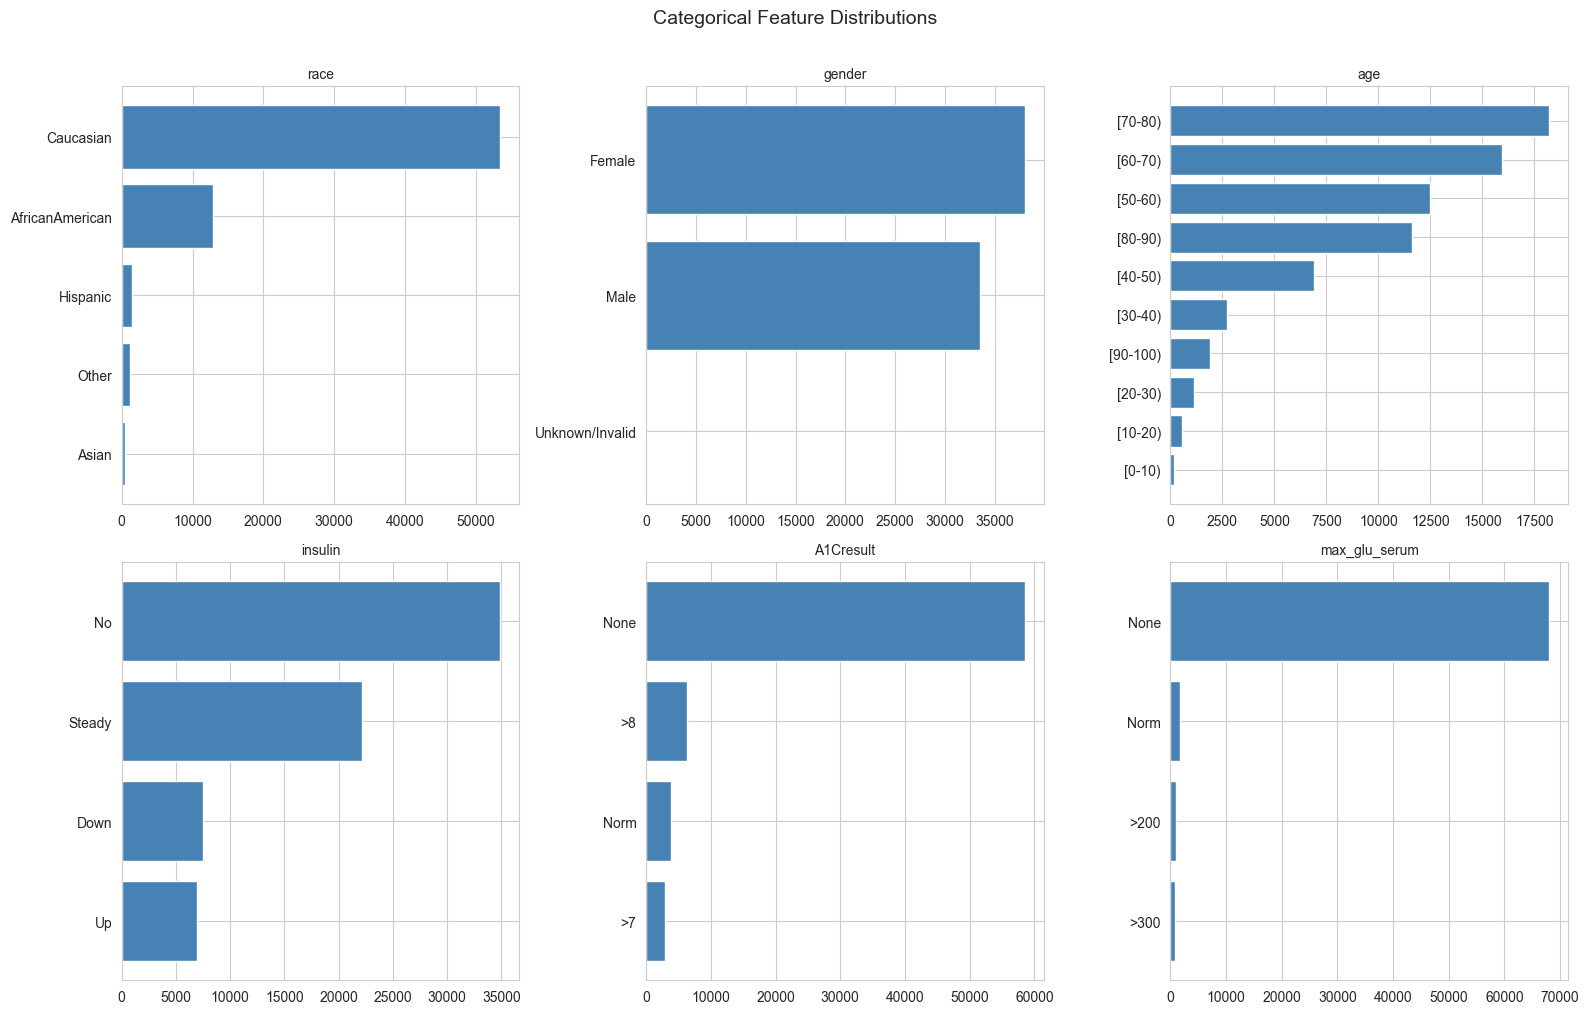

In [13]:
cat_cols_to_plot = [c for c in ['race', 'gender', 'age', 'insulin', 'A1Cresult', 'max_glu_serum'] if c in df.columns]
plot_categorical_bars(df, cat_cols_to_plot)

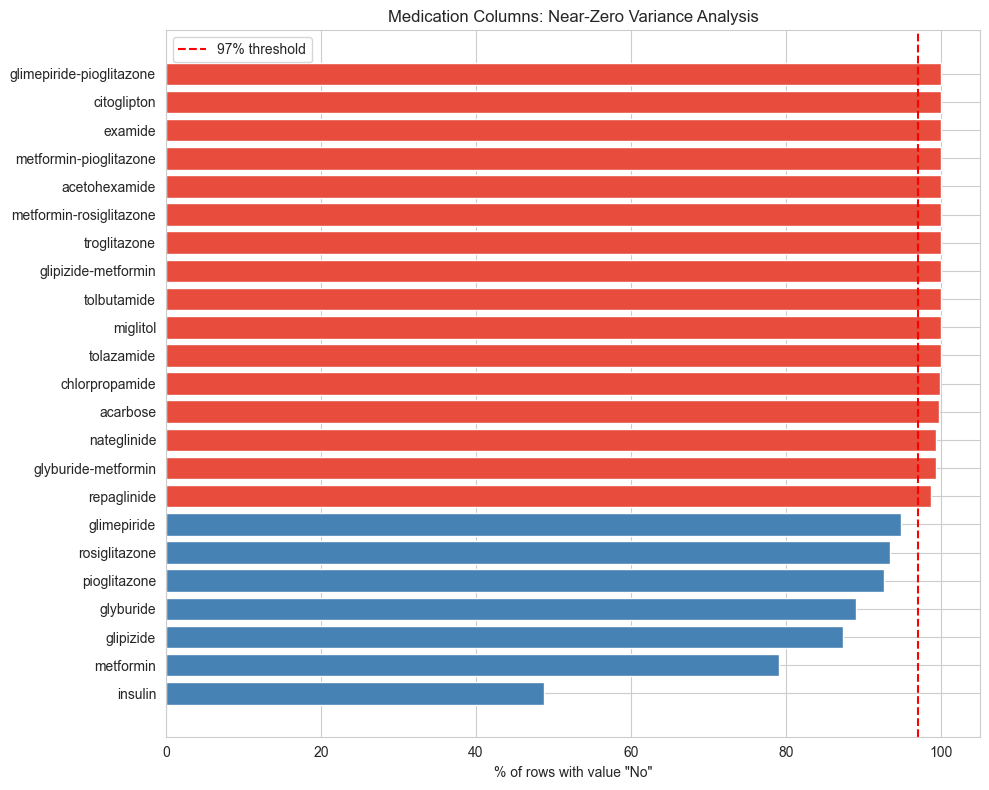


Near-zero variance medications to drop: 16
  repaglinide: 98.7% No
  nateglinide: 99.3% No
  chlorpropamide: 99.9% No
  acetohexamide: 100.0% No
  tolbutamide: 100.0% No
  acarbose: 99.7% No
  miglitol: 100.0% No
  troglitazone: 100.0% No
  tolazamide: 100.0% No
  examide: 100.0% No
  citoglipton: 100.0% No
  glyburide-metformin: 99.3% No
  glipizide-metformin: 100.0% No
  glimepiride-pioglitazone: 100.0% No
  metformin-rosiglitazone: 100.0% No
  metformin-pioglitazone: 100.0% No


In [14]:
no_pct_series, nzv_med_cols = medication_variance_analysis(df, MEDICATION_COLS)
print(f'\nNear-zero variance medications to drop: {len(nzv_med_cols)}')
for col in nzv_med_cols:
    print(f'  {col}: {no_pct_series[col]:.1f}% No')

Features with >97% identical values carry negligible information. Retaining them would increase dimensionality without improving discriminative power.

> **Key Takeaway:** Utilization features are heavily skewed (candidates for log transform). 16 of 23 medication columns have near-zero variance and should be dropped. The age distribution peaks at 70--80, consistent with diabetes prevalence in elderly populations.

---

## 7. Bivariate Analysis

**Goal:** Examine how individual features relate to the readmission outcome.

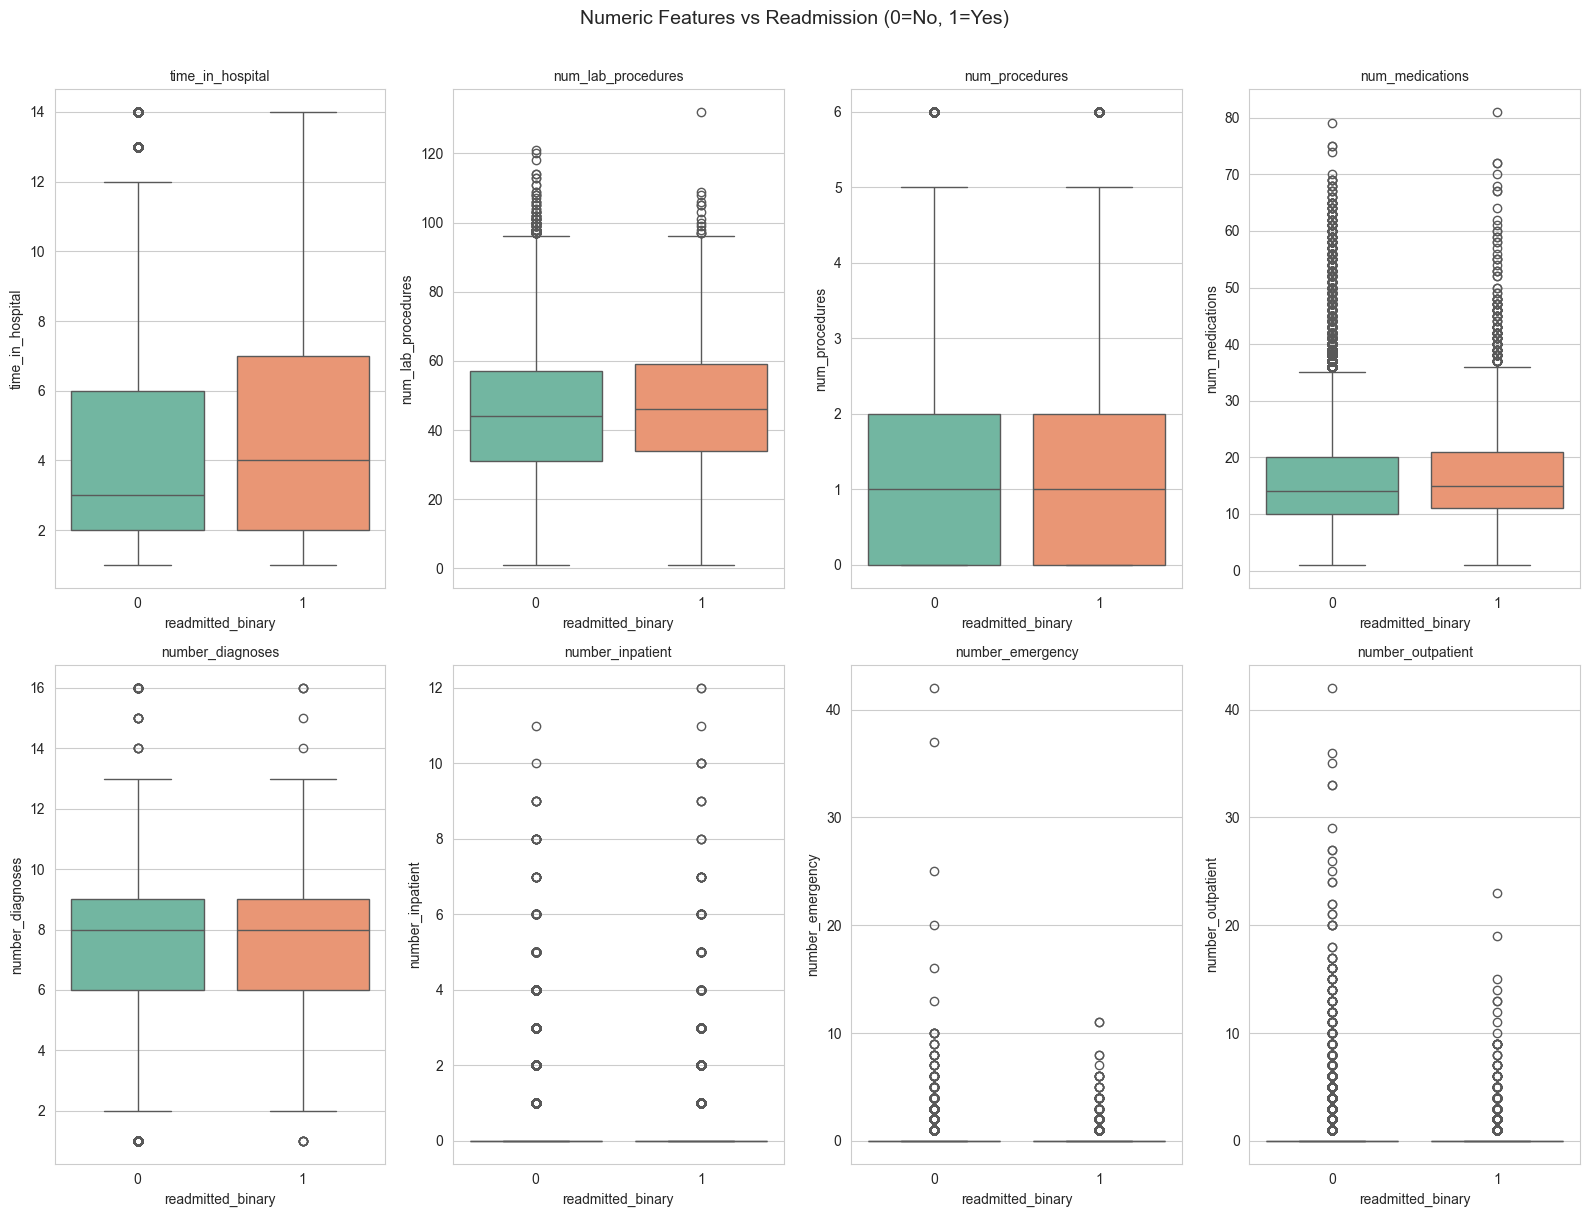

In [15]:
box_features = [c for c in ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_diagnoses', 'number_inpatient',
                'number_emergency', 'number_outpatient'] if c in df.columns]
plot_bivariate_boxplots(df, box_features, 'readmitted_binary')

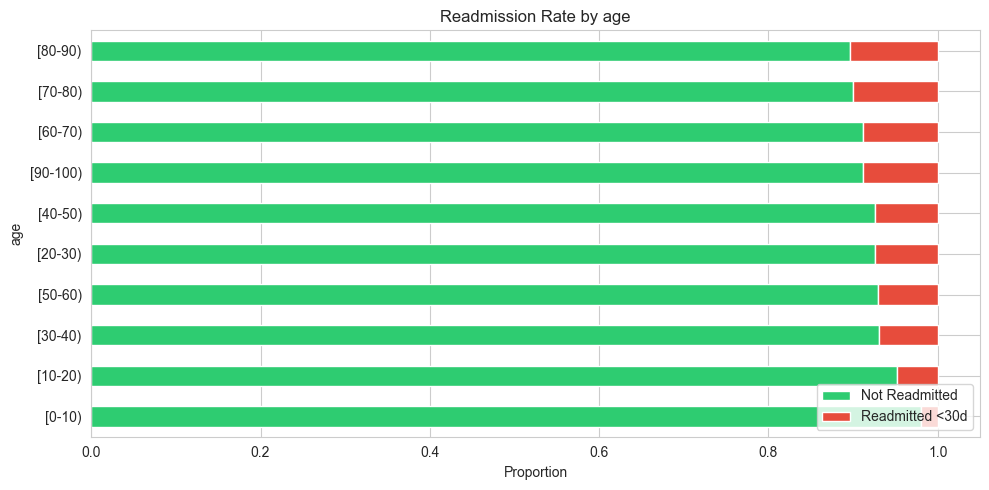

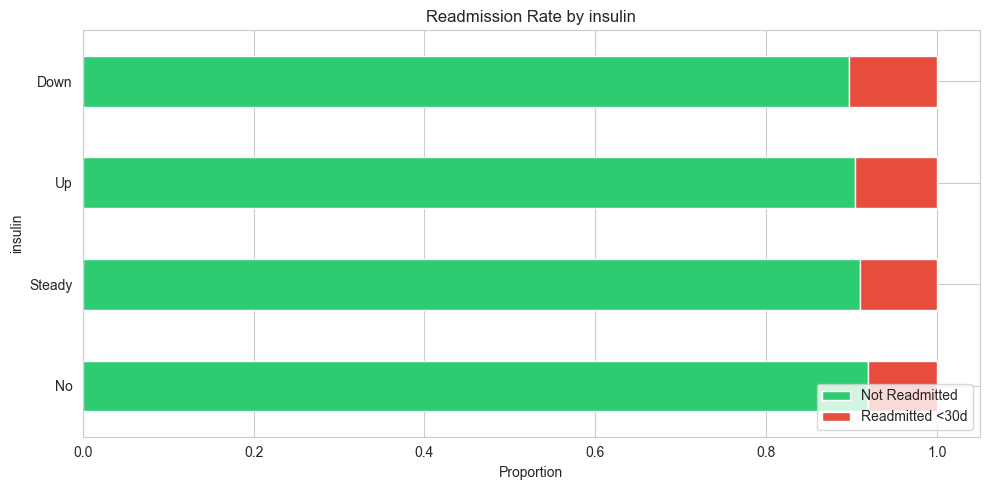

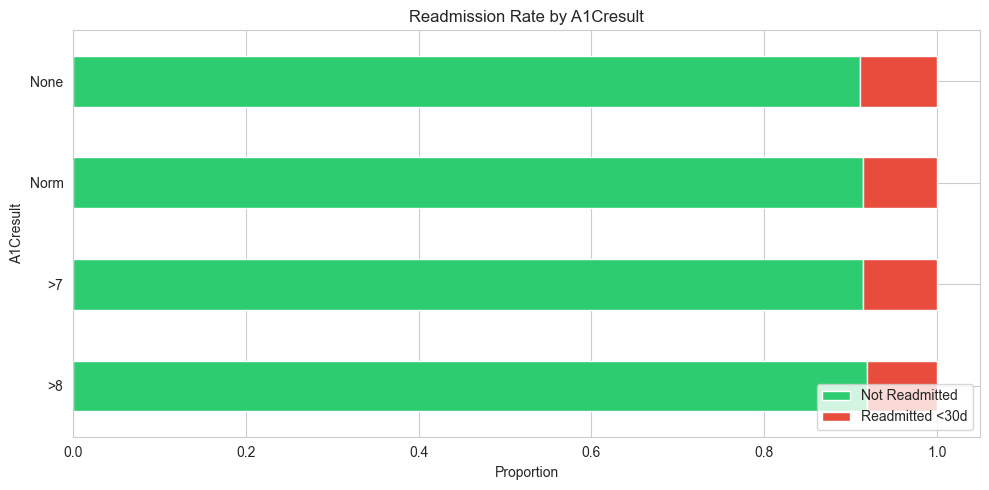

In [16]:
for cat in ['age', 'insulin', 'A1Cresult']:
    if cat in df.columns:
        plot_stacked_proportions(df, cat, 'readmitted_binary', top_n=15)

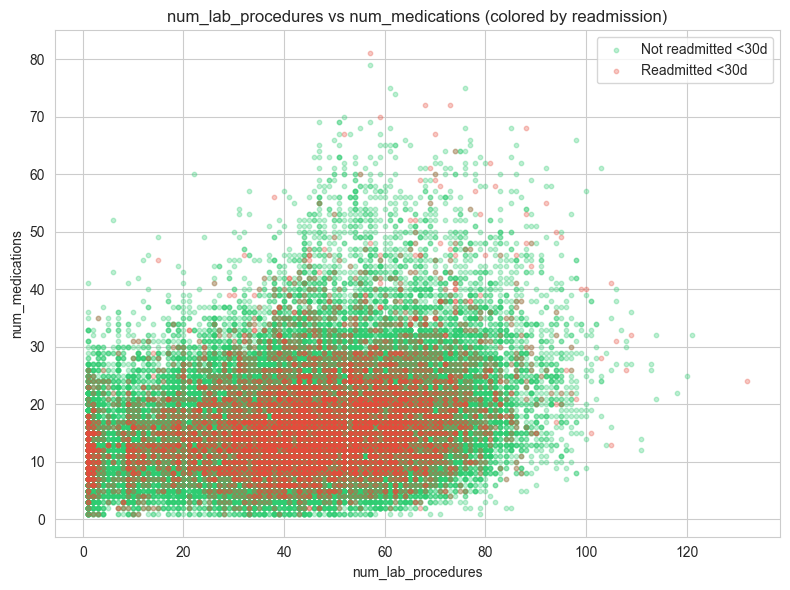

In [17]:
plot_scatter(df, 'num_lab_procedures', 'num_medications', 'readmitted_binary')

**Observations:**
- **`number_inpatient`** and **`number_emergency`** show visibly higher medians for readmitted patients -- prior healthcare utilization is the strongest signal.
- The scatter plot reveals no clean linear decision boundary between classes, suggesting that non-linear models or rich feature combinations will be needed.
- Readmission rates vary across age brackets and insulin management patterns, confirming these as informative features.

> **Key Takeaway:** Prior hospitalization history is the most discriminative feature family. No single feature pair separates the classes cleanly.

---

## 8. Outlier Detection

**Goal:** Identify extreme values and determine whether they represent data errors or meaningful clinical variation.

We apply Tukey's (1977) Interquartile Range method: a value is flagged as an outlier if it falls below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

In [18]:
outlier_cols = [c for c in hist_cols if c in df.columns]
outlier_df = detect_outliers_iqr(df, outlier_cols)
print(outlier_df.to_string(index=False))

                 feature   Q1   Q3  IQR  lower_bound  upper_bound  outlier_count  outlier_pct
       number_outpatient  0.0  0.0  0.0          0.0          0.0           9306    13.012109
        number_inpatient  0.0  0.0  0.0          0.0          0.0           8441    11.802623
discharge_disposition_id  1.0  3.0  2.0         -2.0          6.0           7135     9.976509
        number_emergency  0.0  0.0  0.0          0.0          0.0           5204     7.276490
     admission_source_id  1.0  7.0  6.0         -8.0         16.0           5110     7.145054
          num_procedures  0.0  2.0  2.0         -3.0          5.0           3956     5.531475
         num_medications 10.0 20.0 10.0         -5.0         35.0           1925     2.691630
        time_in_hospital  2.0  6.0  4.0         -4.0         12.0           1464     2.047037
       admission_type_id  1.0  3.0  2.0         -2.0          6.0            312     0.436254
        number_diagnoses  6.0  9.0  3.0          1.5        

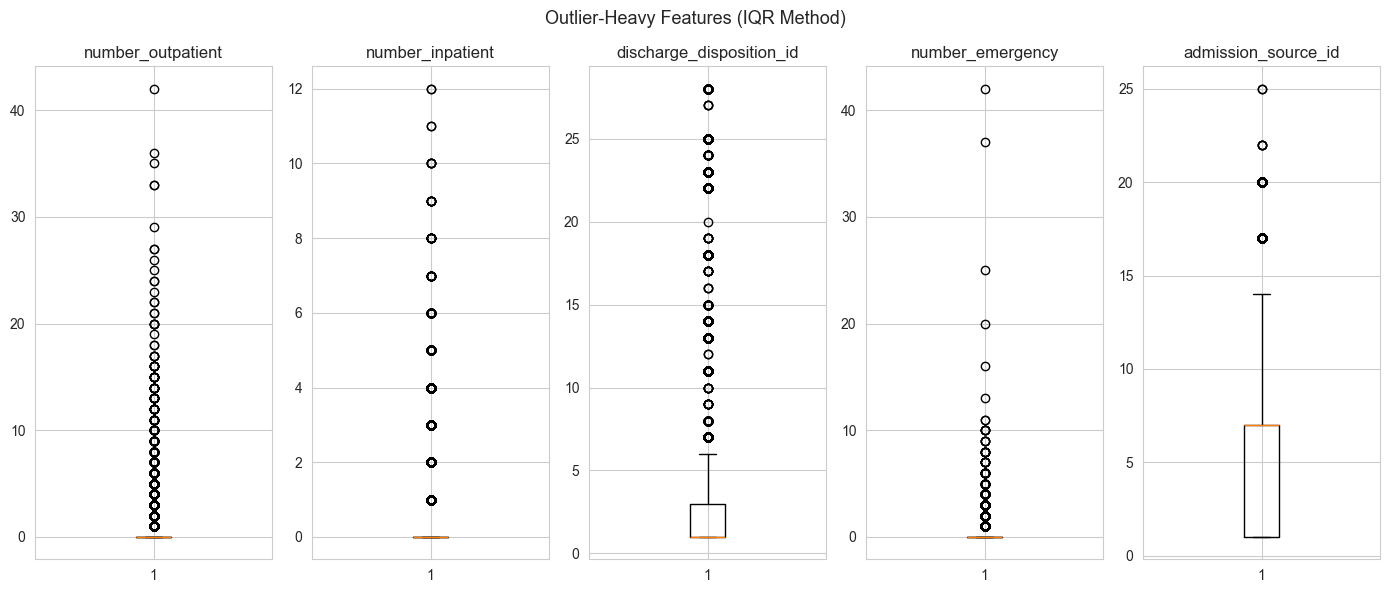

In [19]:
top_outlier_features = outlier_df.head(5)['feature'].tolist()
plot_outlier_boxplots(df, top_outlier_features)

#### Clinical vs. Statistical Outliers

Not all statistical outliers are errors. In clinical data, extreme values often represent the very patients we most want to identify:

| Feature | Classification | Rationale | Treatment |
|---------|---------------|-----------|----------|
| `number_outpatient` | Clinically meaningful | High values = frequent utilizers, a known risk factor | Cap at 1st/99th percentile |
| `number_emergency` | Clinically meaningful | Frequent ER visits indicate chronic instability | Cap at 1st/99th percentile |
| `number_inpatient` | Clinically meaningful | Multiple prior admissions = high disease burden | Cap at 1st/99th percentile |

We cap rather than remove: **removing these patients would bias the model against detecting the highest-risk individuals.**

> **Key Takeaway:** Outliers in utilization features are genuine clinical extremes, not data-entry errors. Winsorization (percentile capping) preserves their signal while limiting leverage.

---

## 9. Correlation Analysis

**Goal:** Identify redundant features (multicollinearity) and features most associated with readmission.

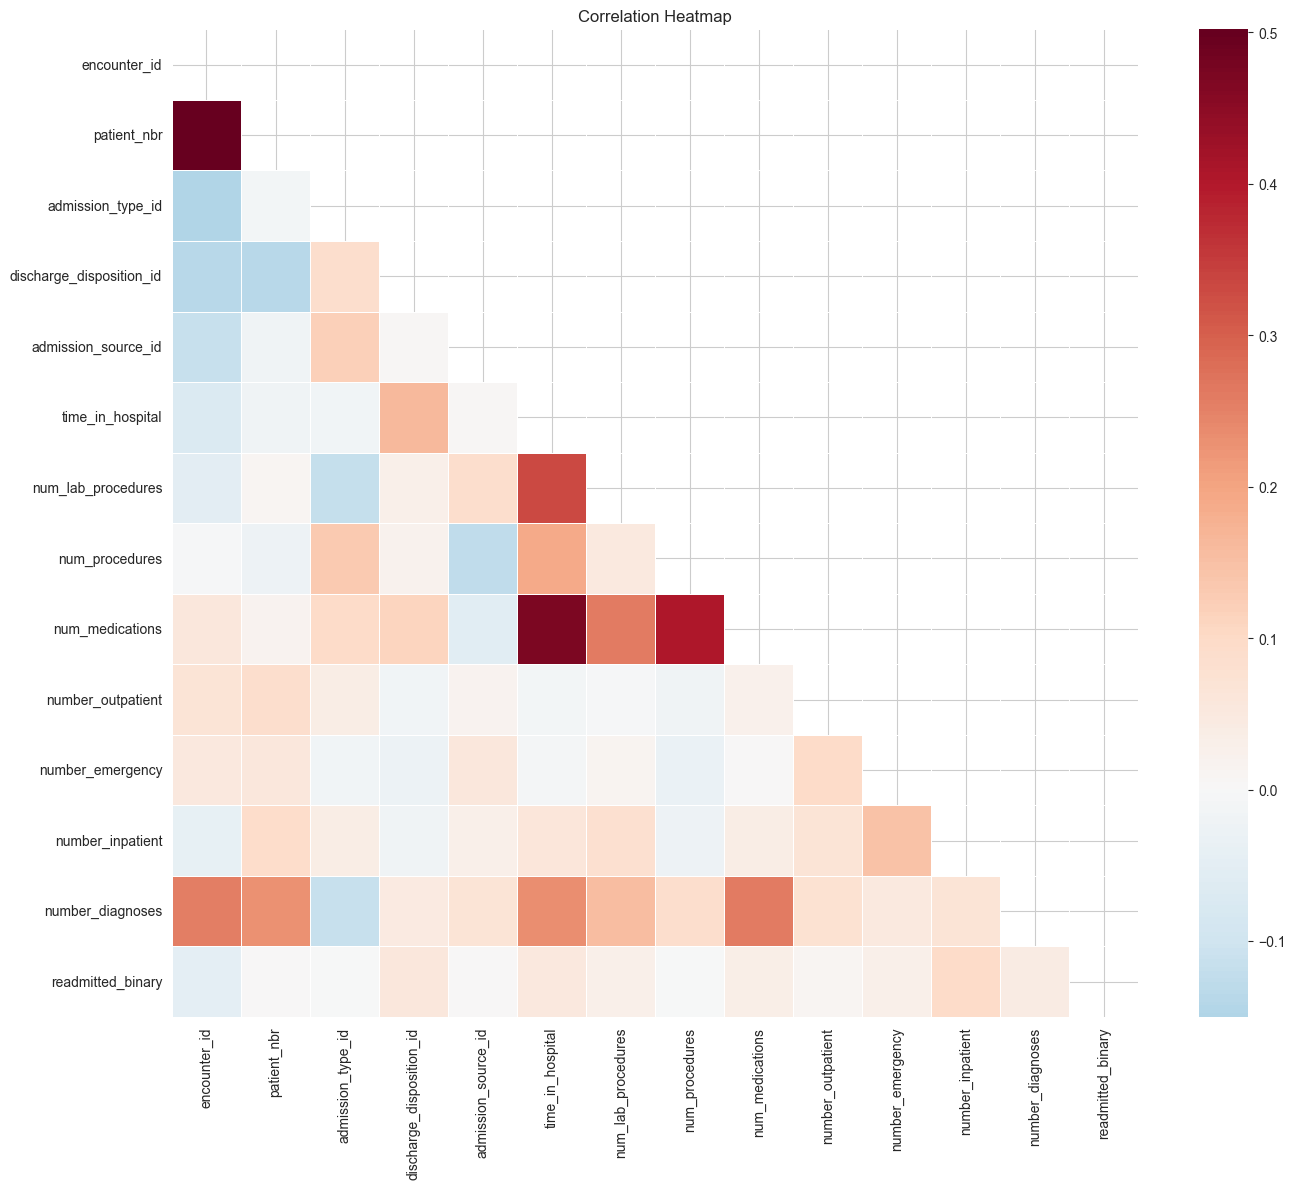

In [20]:
corr_matrix = plot_correlation_heatmap(df)

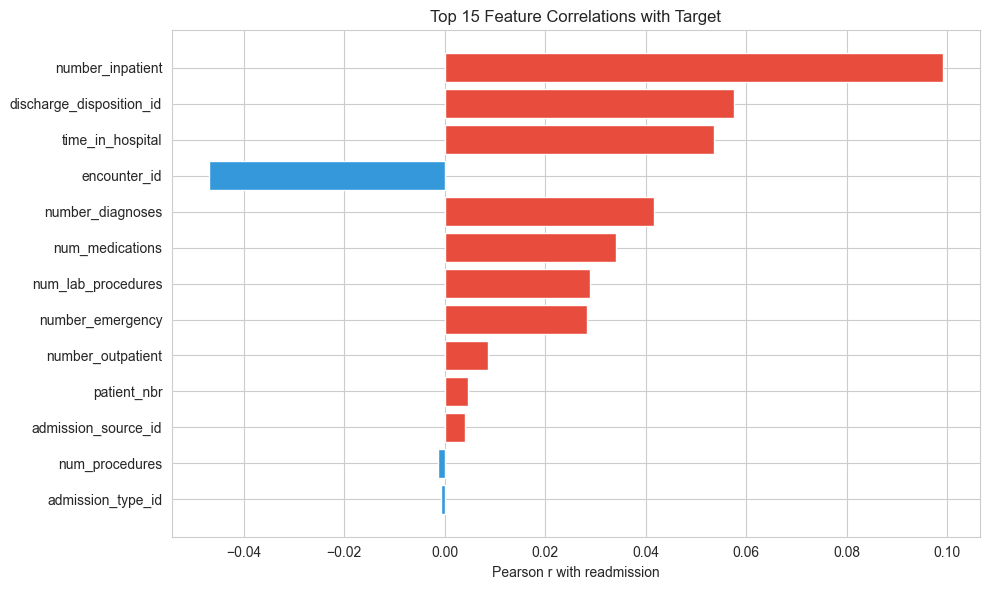

In [21]:
target_corr = correlation_with_target(corr_matrix, 'readmitted_binary')

fig, ax = plt.subplots(figsize=(10, 6))
top_corr = target_corr.head(15)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_xlabel('Pearson r with readmission')
ax.set_title('Top 15 Feature Correlations with Target')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
mc_pairs = find_multicollinear(corr_matrix, threshold=0.95)
if mc_pairs:
    print('Multicollinear pairs (|r| > 0.95):')
    for f1, f2, r in mc_pairs:
        print(f'  {f1} <-> {f2}: r = {r:.4f}')
else:
    print('No multicollinear pairs found (|r| > 0.95).')

No multicollinear pairs found (|r| > 0.95).


**Important caveat:** Pearson correlation captures only *linear* associations. Weak Pearson correlations do not mean features are uninformative -- non-linear relationships (captured by tree-based models) may still exist.

> **Key Takeaway:** Individual linear correlations with the target are weak (|r| < 0.1), consistent with the complexity of clinical readmission prediction. No feature pairs exceed the r > 0.95 multicollinearity threshold at this stage.

---

## 10. EDA Summary

| # | Finding | Implication |
|---|---------|------------|
| 1 | **~9% positive class** | Accuracy is misleading; use precision/recall/F1; stratified splitting required |
| 2 | **3 columns > 40% missing** | weight (97%, MNAR), medical_specialty (49%, MAR), payer_code (40%, MAR) -- all dropped |
| 3 | **Extreme skewness in utilization features** | number_outpatient/emergency/inpatient have skew > 5 -- candidates for log1p transform |
| 4 | **16 near-zero-variance medication columns** | >97% identical values; uninformative, dropped to reduce dimensionality |
| 5 | **Prior hospitalization is the strongest predictor** | number_inpatient, number_emergency show clearest bivariate association with readmission |
| 6 | **Diagnosis codes have 700+ unique values each** | ICD-9 codes must be grouped into ~10 clinical categories to avoid curse of dimensionality |
| 7 | **Outliers are clinically meaningful** | Extreme utilization values represent real high-risk patients, not data errors |

---

## 11. Preprocessing Pipeline

**Goal:** Transform the raw data into a clean, fully numeric representation suitable for machine learning.

The pipeline applies the following steps in sequence, printing the dataset shape after each operation for transparency.

In [23]:
print(f'Starting shape: {df.shape}\n')

# 1. Drop identifiers (no predictive value)
df = drop_ids(df)

# 2. Drop columns exceeding 40% missing threshold
df = drop_high_missing(df)

# 3. Drop near-zero variance medication columns
df = drop_nzv_medications(df, nzv_med_cols)

# 4. Remove patients who expired or entered hospice (cannot be readmitted)
df = remove_deceased(df)

# 5. Remove invalid gender entries
df = remove_invalid_gender(df)

# 6. Impute remaining missing values
df = impute_missing(df)

assert df.isnull().sum().sum() == 0, 'Missing values remain!'
print('\nAll missing values resolved.')

Starting shape: (71518, 50)

[Drop IDs] Shape: 71518 rows x 48 columns
[Drop high-missing columns] Shape: 71518 rows x 45 columns
[Drop near-zero variance meds] Shape: 71518 rows x 29 columns
  Removed 1545 deceased/hospice rows
[Remove deceased/hospice] Shape: 69973 rows x 29 columns
  Removed 3 invalid gender rows
[Remove invalid gender] Shape: 69970 rows x 29 columns
  Imputed race with mode: 'Caucasian'
  Imputed diag_1 with 'Missing'
  Imputed diag_2 with 'Missing'
  Imputed diag_3 with 'Missing'
[Impute missing] Shape: 69970 rows x 29 columns

All missing values resolved.


In [24]:
# 7. Encode ordinal features
df = encode_age(df)             # Age brackets -> numeric midpoints
df = encode_medications(df)     # No=0, Steady=1, Down=2, Up=3
df = encode_lab_results(df)     # Ordinal encoding for A1Cresult, max_glu_serum

# 8. Encode binary features
df = encode_binaries(df)        # gender, change, diabetesMed

# 9. Group ICD-9 diagnosis codes into clinical categories, then one-hot encode
df = group_diagnoses(df)

# 10. One-hot encode remaining nominal features
df = one_hot_encode_categoricals(df)

# 11. Cap outliers at 1st/99th percentile (winsorization)
outlier_cap_cols = [c for c in ['number_outpatient', 'number_emergency', 'number_inpatient'] if c in df.columns]
df = cap_outliers(df, outlier_cap_cols)

print(f'\nPreprocessed shape: {df.shape}')

[Encode age] Shape: 69970 rows x 29 columns
[Encode medications (7 cols)] Shape: 69970 rows x 29 columns
[Encode lab results] Shape: 69970 rows x 29 columns
[Encode binaries] Shape: 69970 rows x 29 columns


[Group & encode diagnoses] Shape: 69970 rows x 74 columns


[One-hot encode categoricals] Shape: 69970 rows x 121 columns
[Cap outliers] Shape: 69970 rows x 121 columns

Preprocessed shape: (69970, 121)


> **Key Takeaway:** The preprocessing pipeline systematically handles missingness, encodes features according to their measurement scale (ordinal vs. nominal vs. binary), groups high-cardinality codes, and treats outliers conservatively.

---

## 12. Feature Engineering

**Goal:** Construct new features that capture domain knowledge not directly represented in the raw data.

Good features encode expert intuition: a patient's *total prior utilization* may be more predictive than the separate outpatient/emergency/inpatient counts; the *number of medication changes* during a stay signals treatment complexity.

In [25]:
# Domain-driven feature construction
df = create_visit_features(df)                                          # total_visits_prior
med_cols_in_df = [c for c in MEDICATION_COLS if c in df.columns]
df = create_med_change_feature(df, med_cols_in_df)                      # n_med_changes
df = create_test_flags(df)                                              # a1c_tested, glu_tested
df = create_service_utilization(df)                                     # service_utilization

# Discretization of continuous feature
df = bin_time_in_hospital(df)                                           # stay_short/medium/long

# Log transform for heavily skewed features
skew_cols = [c for c in ['number_outpatient', 'number_emergency', 'number_inpatient'] if c in df.columns]
df = log_transform_skewed(df, skew_cols, skew_threshold=2.0)

print_step('After feature engineering', df)

  Created: total_visits_prior


  Created: n_med_changes
  Created: a1c_tested
  Created: glu_tested
  Created: service_utilization
  Created: stay_short, stay_medium, stay_long
  Log-transformed: ['number_outpatient', 'number_emergency', 'number_inpatient']
[After feature engineering] Shape: 69970 rows x 132 columns


In [26]:
# Remove features with near-zero variance (from one-hot encoding explosion)
target_col = df['readmitted_binary'].copy()
df_features = df.drop(columns=['readmitted_binary'])
df_features = remove_low_variance(df_features, threshold=0.01)
df = pd.concat([df_features, target_col], axis=1)

  Dropped 29 low-variance features: ['diag_1_group_Blood', 'race_Asian', 'admission_type_id_4', 'admission_type_id_7', 'admission_type_id_8', 'discharge_disposition_id_10', 'discharge_disposition_id_12', 'discharge_disposition_id_15', 'discharge_disposition_id_16', 'discharge_disposition_id_17']...
[Variance filter] Shape: 69970 rows x 102 columns


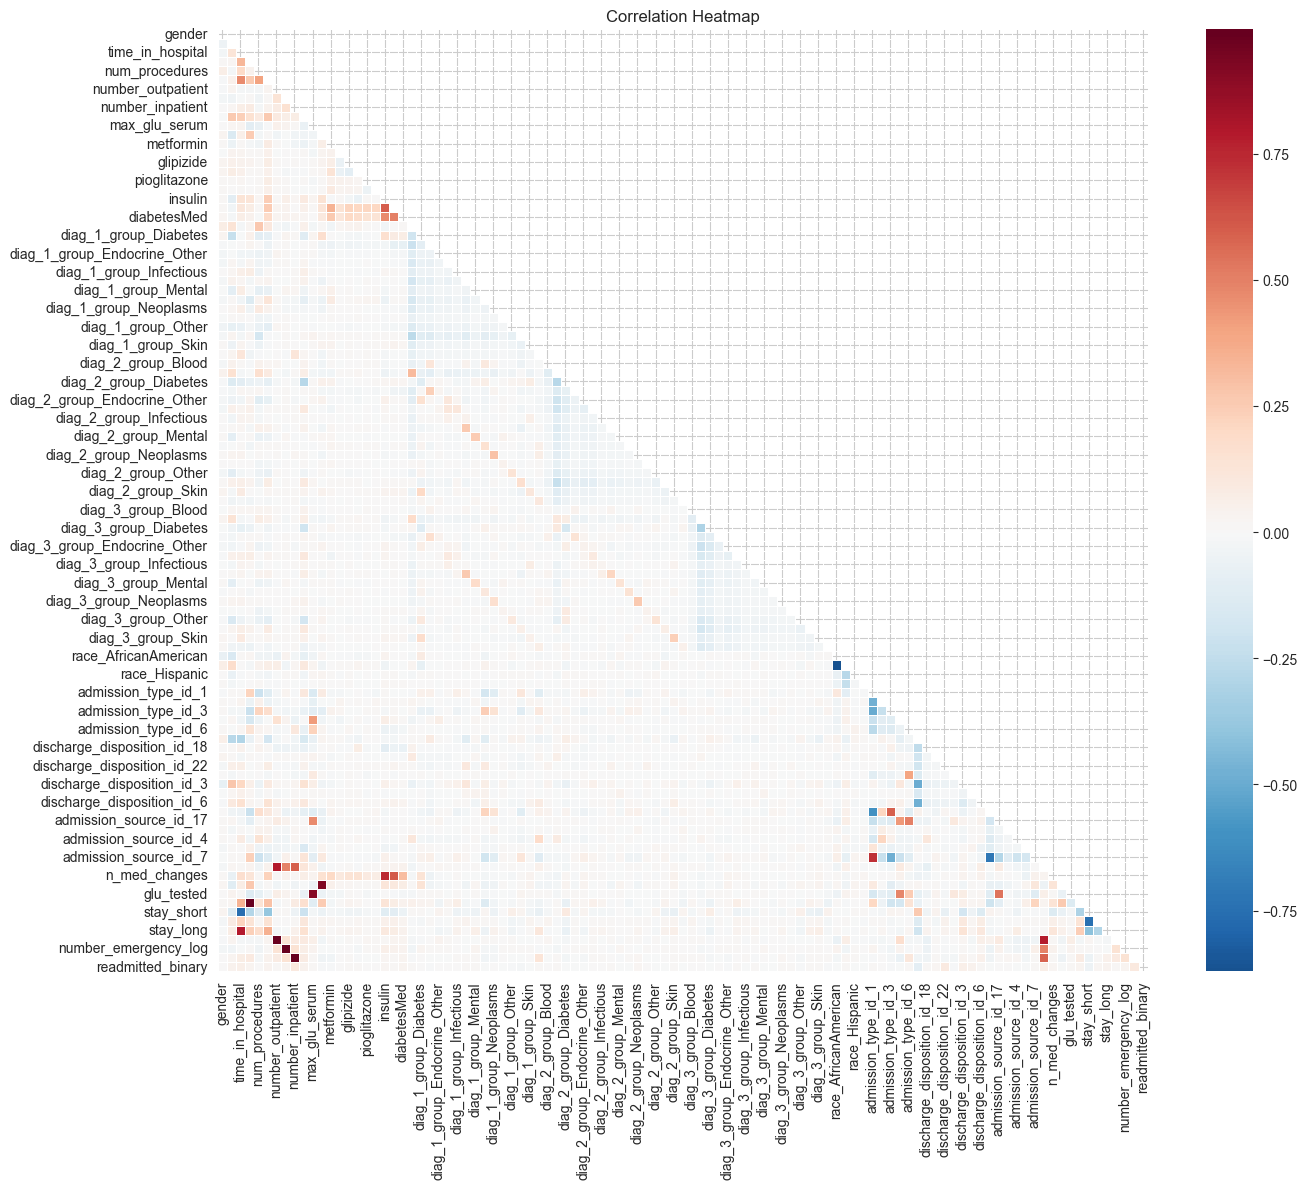

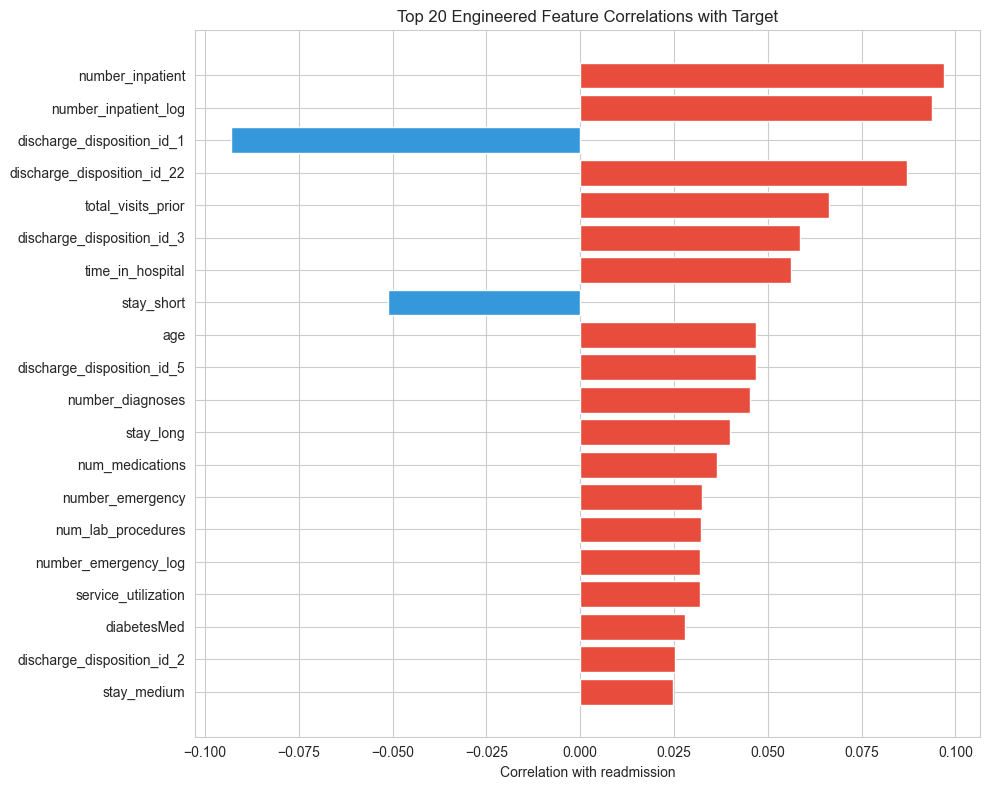

In [27]:
# Final correlation analysis on engineered features
corr_final = plot_correlation_heatmap(df)

target_corr_final = correlation_with_target(corr_final, 'readmitted_binary')
fig, ax = plt.subplots(figsize=(10, 8))
top20 = target_corr_final.head(20)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top20.values]
ax.barh(top20.index, top20.values, color=colors)
ax.set_xlabel('Correlation with readmission')
ax.set_title('Top 20 Engineered Feature Correlations with Target')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
# Remove multicollinear pairs (r > 0.95)
mc_pairs_final = find_multicollinear(corr_final, threshold=0.95)
if mc_pairs_final:
    cols_to_drop = set()
    for f1, f2, r in mc_pairs_final:
        print(f'  {f1} <-> {f2}: r = {r:.4f}')
        if abs(corr_final[f1]['readmitted_binary']) < abs(corr_final[f2]['readmitted_binary']):
            cols_to_drop.add(f1)
        else:
            cols_to_drop.add(f2)
    df = df.drop(columns=list(cols_to_drop), errors='ignore')
    print(f'Dropped {len(cols_to_drop)} redundant features.')
else:
    print('No multicollinear pairs found.')

print_step('Final feature set', df)

  num_lab_procedures <-> service_utilization: r = 0.9962
  number_outpatient <-> number_outpatient_log: r = 0.9792
  number_emergency <-> number_emergency_log: r = 0.9928
  number_inpatient <-> number_inpatient_log: r = 0.9843
Dropped 4 redundant features.
[Final feature set] Shape: 69970 rows x 99 columns


> **Key Takeaway:** Five domain-driven features were constructed, skewed features were log-transformed, and dimensionality was reduced through variance filtering and multicollinearity pruning.

---

## 13. Train-Test Split & Feature Scaling

**Goal:** Create a reproducible, stratified partition for unbiased model evaluation.

In [29]:
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples x {X_train.shape[1]} features')
print(f'Test set:      {X_test.shape[0]:,} samples x {X_test.shape[1]} features')
print(f'\nClass balance (train): {y_train.mean():.1%} positive')
print(f'Class balance (test):  {y_test.mean():.1%} positive')

Training set:  55,976 samples x 98 features
Test set:      13,994 samples x 98 features

Class balance (train): 9.0% positive
Class balance (test):  9.0% positive


In [30]:
# Feature scaling: tree-based models operate on raw scales,
# while distance-based models (SVM, kNN, neural nets) require standardization.
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train.to_csv('../data/processed/X_train_unscaled.csv', index=False)
X_test.to_csv('../data/processed/X_test_unscaled.csv', index=False)

X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, numeric_features)

X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print('Saved: scaled + unscaled train/test sets to data/processed/')

Saved: scaled + unscaled train/test sets to data/processed/


> **Key Takeaway:** The scaler is fit exclusively on training data and then applied to the test set -- a critical safeguard against data leakage. Both scaled and unscaled versions are persisted for model-appropriate usage in Phase 2.

---

## 14. Phase 1 Summary

#### Data Flow

| Stage | Rows | Columns | Action |
|-------|------|---------|--------|
| Raw | 101,766 | 50 | Load, replace `?` with NaN |
| Deduplicated | ~71,500 | 50 | First encounter per patient |
| Cleaned | ~70,000 | ~29 | Drop IDs, high-missing, NZV meds, deceased |
| Encoded | ~70,000 | ~121 | Ordinal, binary, one-hot encoding |
| Engineered | ~70,000 | ~132 | New features, binning, log transforms |
| Filtered | ~70,000 | **98** | Variance threshold + multicollinearity pruning |
| Train / Test | 55,976 / 13,994 | 98 | 80/20 stratified split |

#### Design Principles Applied

1. **No data leakage:** Patient deduplication, train-only scaler fitting, stratified splitting.
2. **Domain-informed decisions:** ICD-9 grouping, clinically meaningful outlier treatment, medication encoding.
3. **Dimensionality management:** Dropped irrelevant IDs, near-zero variance features, and multicollinear pairs.
4. **Model-agnostic preparation:** Both raw and standardized feature sets ready for tree-based and distance-based models.

The processed dataset is ready for Phase 2: model training, evaluation, and comparison.